In [205]:
import pandas as pd
import numpy as np
df = pd.read_csv('report_Lisbon_FDR1.pg_matrix.csv')

In [206]:
 df.shape

(492, 84)

In [207]:
df

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,C:\Manadas\share_PC_Manadas\DanielaAraujo\S01_LIS020_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S02_LIS054_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S03_LIS044_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S04_LIS053_10uLof30uL_SWATH.wiff.dia,...,C:\Manadas\share_PC_Manadas\DanielaAraujo\S67_LIS087_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S68_LIS088_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S69_LIS094_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S70_LIS096_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S71_LIS097_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S72_LIS102_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S73_LIS103_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S74_LIS104_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S75_LIS116_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S76_LIS117_10uLof30uL_SWATH.wiff.dia
0,A0A075B6H7,KV37_HUMAN,IGKV3-7,Probable non-functional immunoglobulin kappa v...,2,1,2765.7200,1680.4800,7286.8700,3478.590,...,2225.7300,2324.000,1699.9000,5204.950,3062.5300,3934.2400,6397.0100,4505.5600,4620.9100,3298.9600
1,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,22.2270,87.9395,273.3420,NaN,...,27.9519,NaN,30.9206,100.591,49.8716,47.9074,127.1660,90.1098,17.0926,31.2933
2,A0A075B6J9,LV218_HUMAN,IGLV2-18,Immunoglobulin lambda variable 2-18,2,1,72.3171,37.3179,60.1143,104.516,...,42.1034,NaN,27.6053,NaN,39.6909,NaN,85.5746,37.5523,20.3119,35.9497
3,A0A075B6K5,LV39_HUMAN,IGLV3-9,Immunoglobulin lambda variable 3-9,2,1,203.0530,123.1380,398.9520,358.261,...,127.8960,113.068,51.2467,279.736,128.8590,96.3158,305.1740,129.2580,134.3460,65.5010
4,A0A075B6P5;P01615;A0A087WW87;P01614,KV228_HUMAN;KV240_HUMAN;KVD28_HUMAN;KVD40_HUMAN,IGKV2-28;IGKV2-40;IGKV2D-28;IGKV2D-40,Immunoglobulin kappa variable 2-28,1,0,1294.4100,344.9990,1882.5700,443.939,...,896.3350,398.447,460.9030,711.119,1378.9600,924.8090,1985.1500,534.0280,1205.1000,1386.6500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,Q9Y6R7,FCGBP_HUMAN,FCGBP,IgGFc-binding protein,33,33,377.4010,271.4500,913.5500,507.202,...,301.7030,566.379,337.6280,726.382,747.0370,758.3560,1125.8300,1297.8200,1385.2500,686.2130
488,cRAP-P00760,cRAP-TRY1_BOVIN,NaN,Cationic trypsin,5,5,233676.0000,211696.0000,337200.0000,307022.000,...,262902.0000,247006.000,270748.0000,293007.000,267243.0000,330518.0000,275874.0000,347417.0000,375463.0000,257574.0000
489,cRAP-P00761,cRAP-TRYP_PIG,NaN,Trypsin,2,2,341.3970,293.5920,410.1920,474.222,...,258.8920,455.180,493.1050,504.033,452.5590,377.1780,248.6950,292.8160,659.7700,439.6180
490,cRAP-P0AEY0,MALE_ECO57,malE,Maltose-binding periplasmic protein,34,34,127100.0000,148222.0000,194553.0000,203412.000,...,163146.0000,147432.000,123615.0000,131137.000,137872.0000,159853.0000,153611.0000,161232.0000,178222.0000,123324.0000


Refining Column Headers for Enhanced Sample Identification

Adjusting column metadata to improve the readability of patient identifiers (IDs) and ensure consistent data visualization.

In [208]:
import re

In [209]:
df.columns = [re.search(r"LIS\d+", col).group(0) if re.search(r"LIS\d+", col) else col for col in df.columns]

Assessment of Technical Replicate Correlation for Data Merging

To evaluate the reproducibility of the measurements, we calculate the correlation between technical replicates. High correlation coefficients justify the subsequent step of averaging the replicates into a single representative sample, thereby reducing noise and simplifying the dataset for downstream analysis.

In [210]:
df_LIS021 = df['LIS021']   # prende tutte le colonne chiamate LIS021

uno = df_LIS021.iloc[:, 0]
due = df_LIS021.iloc[:, 1]

correlazione = uno.corr(due)
print(correlazione)

0.930575654612811


In [211]:
df_LIS021 = df['LIS034']   # prende tutte le colonne chiamate LIS021

uno = df_LIS021.iloc[:, 0]
due = df_LIS021.iloc[:, 1]

correlazione = uno.corr(due)
print(correlazione)

0.9895212069805348


In [212]:
df_LIS021 = df['LIS023']   # prende tutte le colonne chiamate LIS021

uno = df_LIS021.iloc[:, 0]
due = df_LIS021.iloc[:, 1]

correlazione = uno.corr(due)
print(correlazione)

0.9284743321880953


Data Restructuring: Transposition and Feature Selection

The protein expression matrix was transposed to align with standard statistical analysis formats, placing individual patients in rows and protein identifiers in columns. During this process, non-quantitative columns (metadata not representing protein intensities) were removed to ensure the dataset exclusively contains numerical expression values for downstream processing.

In [213]:
df_indexed = df.set_index('Protein.Group')
df_numeric = df_indexed.iloc[:, 5:]
df_matrix_T = df_numeric.T

In [214]:
df_matrix_T

Protein.Group,A0A075B6H7,A0A075B6I0,A0A075B6J9,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6R2,A0A075B6R9;A0A0C4DH68,A0A075B6S2;A0A0A0MRZ7;A2NJV5,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A075B6S9;P0DSN7,...,Q9Y4C0,Q9Y5I4,Q9Y5Y7,Q9Y646,Q9Y6N7,Q9Y6R7,cRAP-P00760,cRAP-P00761,cRAP-P0AEY0,cRAP-P42212
LIS020,2765.72,22.2270,72.3171,203.0530,1294.410,53.0718,785.713,NaN,490.172,NaN,...,475.813,51.8003,60.9571,134.6900,29.8334,377.401,233676.0,341.397,127100.0,188114.0
LIS054,1680.48,87.9395,37.3179,123.1380,344.999,NaN,172.665,248.480,145.149,NaN,...,389.625,26.8569,62.1100,99.1111,24.4571,271.450,211696.0,293.592,148222.0,256793.0
LIS044,7286.87,273.3420,60.1143,398.9520,1882.570,104.9320,1061.150,486.796,895.897,NaN,...,298.168,NaN,88.7272,120.6860,NaN,913.550,337200.0,410.192,194553.0,362921.0
LIS053,3478.59,NaN,104.5160,358.2610,443.939,61.1363,1264.190,NaN,671.084,38.2504,...,341.211,34.7535,67.9932,126.8680,19.7543,507.202,307022.0,474.222,203412.0,382877.0
LIS090,2765.08,54.8819,NaN,128.7230,486.692,NaN,225.964,NaN,316.766,NaN,...,422.239,32.7511,50.5493,86.1335,27.3094,870.229,285967.0,441.323,185203.0,322818.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS102,3934.24,47.9074,NaN,96.3158,924.809,NaN,410.324,290.006,293.059,NaN,...,551.343,23.1060,85.7320,103.7710,28.2173,758.356,330518.0,377.178,159853.0,309709.0
LIS103,6397.01,127.1660,85.5746,305.1740,1985.150,NaN,424.258,391.723,803.771,NaN,...,302.717,13.9528,54.1178,80.2208,23.0786,1125.830,275874.0,248.695,153611.0,286728.0
LIS104,4505.56,90.1098,37.5523,129.2580,534.028,NaN,420.686,NaN,427.967,NaN,...,255.098,NaN,56.8257,87.0760,NaN,1297.820,347417.0,292.816,161232.0,301612.0
LIS116,4620.91,17.0926,20.3119,134.3460,1205.100,NaN,466.842,NaN,551.367,NaN,...,167.741,NaN,52.7447,112.2890,21.9518,1385.250,375463.0,659.770,178222.0,360208.0


Quality Control: Assessment of Missing Values (NaN)

We performed a comprehensive screening of the dataset to quantify missing data (NaN values). The analysis was conducted at two levels: per-protein (column-wise) and per-patient (row-wise). Both absolute counts and percentage distributions were calculated to evaluate data completeness and identify potential outliers or low-quality features

In [215]:
list_prot_nan = df_matrix_T.isna().sum().tolist()

In [216]:
list_examples_nan = df_matrix_T.isna().sum(axis=1).tolist()

In [217]:
df_matrix_T.isna().sum().sum()

5326

In [218]:
perc_prot = []
n_patients = df_matrix_T.shape[0]
for i in list_prot_nan:
    res = (i/n_patients)*100
    perc_prot.append(res)

In [219]:
n_patients

78

In [220]:
perc_examples = []
n_proteins = df_matrix_T.shape[1]
for i in list_examples_nan:
    res_2 = (i/n_proteins)*100
    perc_examples.append(res_2)

In [221]:
n_proteins

492

In [222]:
perc_prot = pd.Series(perc_prot)
perc_prot.describe()

count    492.000000
mean      13.878466
std       22.838294
min        1.282051
25%        1.282051
50%        1.923077
75%       16.666667
max       98.717949
dtype: float64

In [223]:
perc_examples = pd.Series(perc_examples)
perc_examples.describe()

count     78.000000
mean      13.878466
std       10.710693
min        7.113821
25%       10.010163
50%       11.991870
75%       14.634146
max      100.000000
dtype: float64

In [224]:
import matplotlib.pyplot as plt

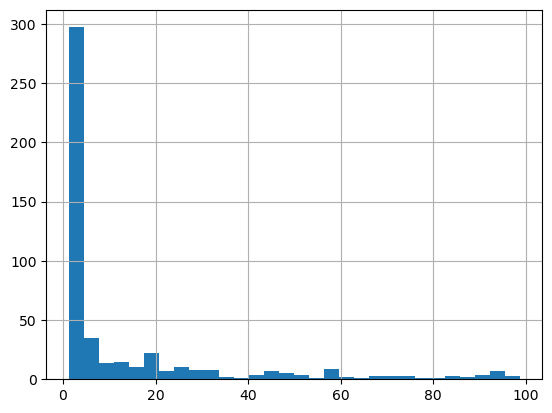

In [225]:
perc_prot.describe()
perc_prot.hist(bins=30)
plt.savefig('distribution_nan_proteins_hist_Lisbon.png')

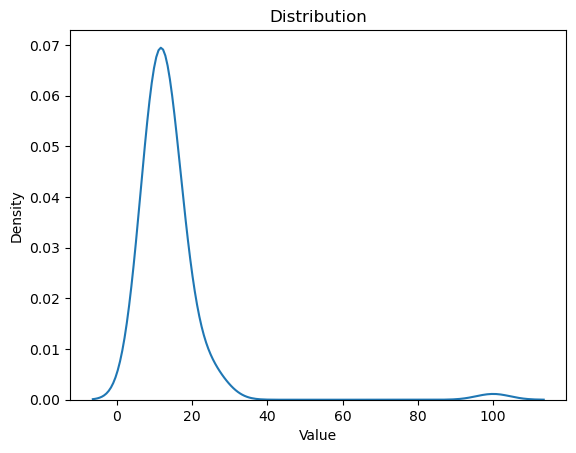

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(perc_examples)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.savefig('distribution_nan_proteins_Lisbon.png')
plt.show()

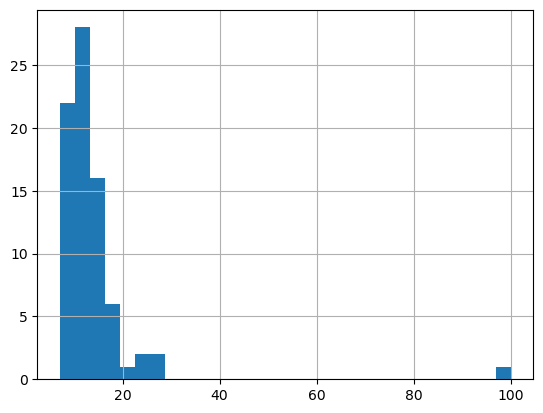

In [227]:
perc_examples.describe()
perc_examples.hist(bins=30)
plt.savefig('distribution_nan_samples_hist_Lisbon.png')

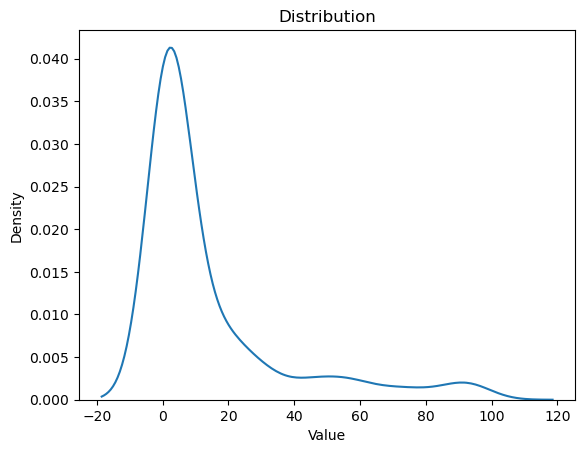

In [228]:
sns.kdeplot(perc_prot)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.savefig('distribution_nan_samples_Lisbon.png')
plt.show()

In [229]:
(perc_prot > 50).sum()

47

In [230]:
(perc_prot > 70).sum()

27

In [231]:
perc_prot.sort_values(ascending=False)

196    98.717949
310    96.153846
472    96.153846
226    94.871795
416    93.589744
         ...    
203     1.282051
198     1.282051
197     1.282051
195     1.282051
491     1.282051
Length: 492, dtype: float64

In [232]:
perc_examples.sort_values(ascending=False)

54    100.000000
58     26.422764
9      25.813008
76     24.390244
57     24.186992
         ...    
6       8.130081
1       7.723577
40      7.723577
5       7.520325
35      7.113821
Length: 78, dtype: float64

Exploratory Data Analysis: Distribution and Correlation Profiling

To assess the overall data quality and consistency, we performed an Exploratory Data Analysis (EDA). A boxplot of protein intensities was generated for each sample to evaluate normalization and identify potential batch effects. Additionally, a Pearson correlation heatmap was constructed to visualize global similarities between patient profiles and ensure biological consistency

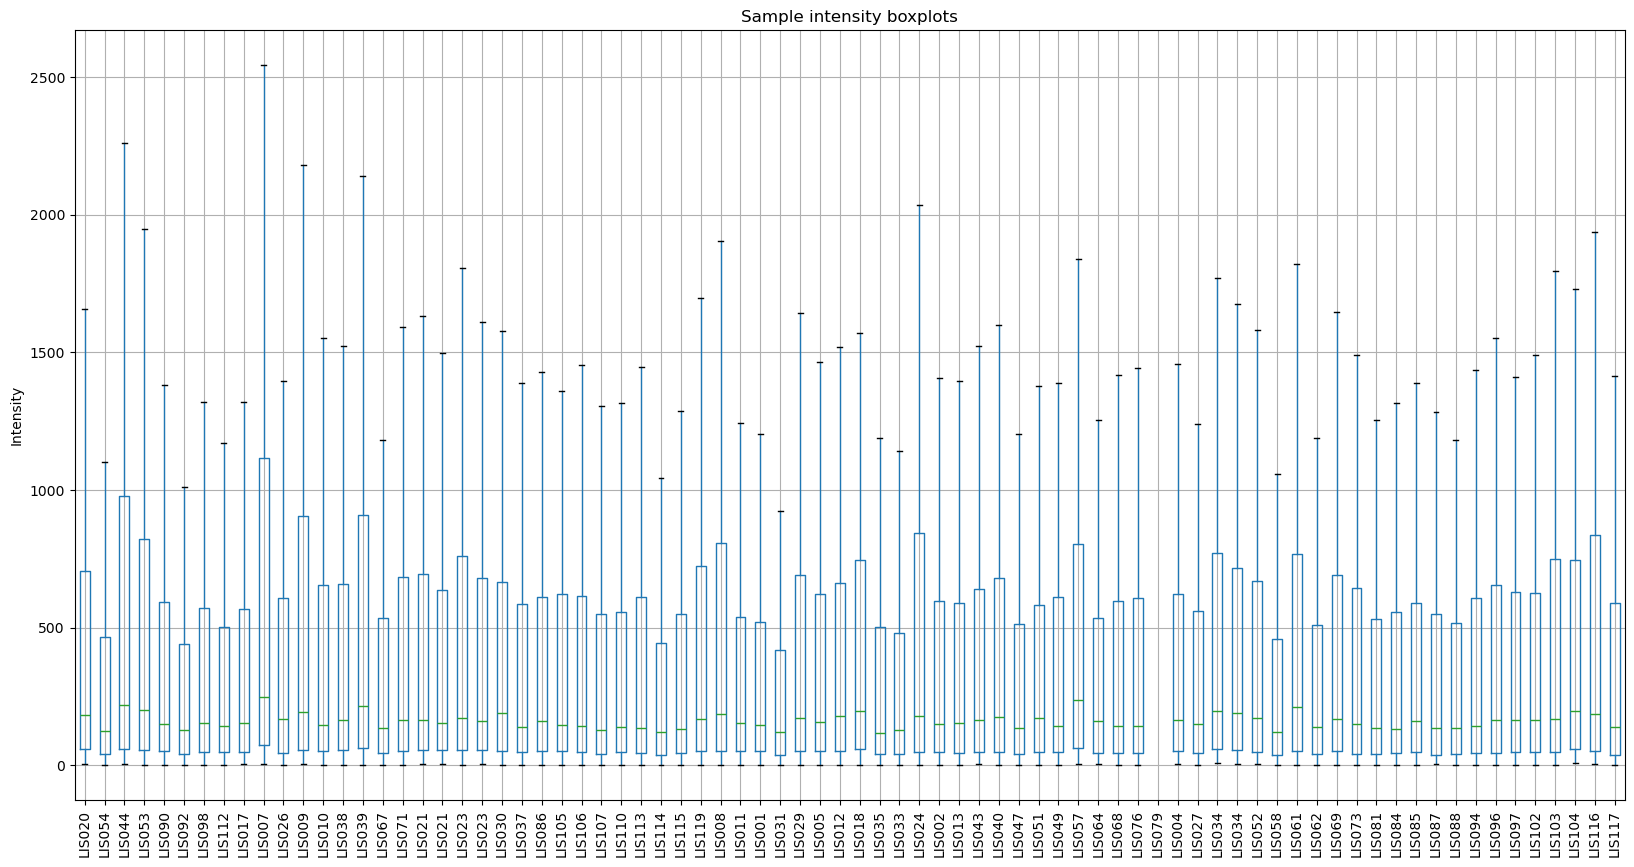

In [233]:
plt.figure(figsize=(20,10))
df_matrix_T.T.boxplot(showfliers=False)
plt.xticks(rotation=90)
plt.ylabel("Intensity")
plt.title("Sample intensity boxplots")
dpi=300
plt.savefig('Boxplot_delle_intensità_per_campione_Lisbon.png')
plt.show()

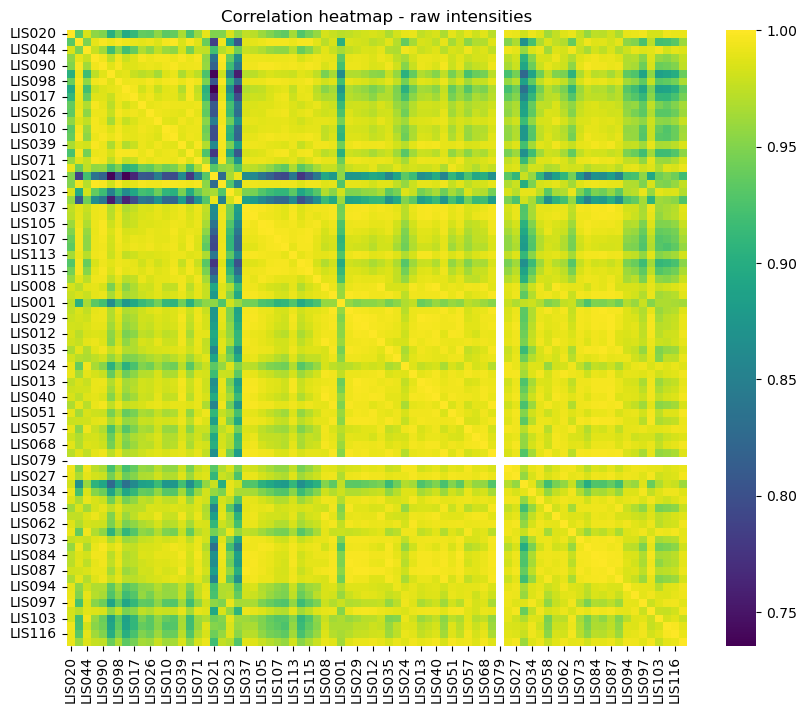

In [234]:
import seaborn as sns

# correlazione tra pazienti
corr_matrix = df_matrix_T.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="viridis")
plt.title("Correlation heatmap - raw intensities")
dpi=300
plt.savefig('Correlation_heatmap.png')
plt.show()

FILTERING

Protein Quality FilteringProteins identified with fewer than two proteotypic peptides ($N.proteotypic < 2$) were excluded to ensure high-confidence identification and reduce false positives.

In [235]:
df = df[df['N.Proteotypic.Sequences'] >= 2]

In [236]:
df['N.Proteotypic.Sequences'].sort_values()

1       2
424     2
199     2
156     2
153     2
       ..
96     51
142    53
150    61
148    74
97     95
Name: N.Proteotypic.Sequences, Length: 351, dtype: int64

In [237]:
# Identifichiamo i contaminanti
contaminanti = df[df['Protein.Group'].str.contains('cRAP', na=False)]

# Stampiamo l'elenco (mostrando il codice e il nome della proteina)
print("Proteine rimosse (cRAP):")
print(contaminanti[['Protein.Group', 'Protein.Names']].to_string(index=False))

# Aggiorniamo il dataset tenendo solo le proteine "buone"
df = df[~df['Protein.Group'].str.contains('cRAP', na=False)]

Proteine rimosse (cRAP):
Protein.Group   Protein.Names
  cRAP-P00760 cRAP-TRY1_BOVIN
  cRAP-P00761   cRAP-TRYP_PIG
  cRAP-P0AEY0      MALE_ECO57
  cRAP-P42212       GFP_AEQVI


In [238]:
df

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,LIS020,LIS054,LIS044,LIS053,...,LIS087,LIS088,LIS094,LIS096,LIS097,LIS102,LIS103,LIS104,LIS116,LIS117
1,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,22.2270,87.9395,273.3420,NaN,...,27.9519,NaN,30.9206,100.5910,49.8716,47.9074,127.1660,90.1098,17.0926,31.2933
15,A0A0A0MS15,HV349_HUMAN,IGHV3-49,Immunoglobulin heavy variable 3-49,2,2,173.9880,323.0540,1077.8600,1051.5700,...,412.3130,181.5050,133.0200,492.7360,383.0870,383.5330,363.1470,457.7140,1721.0900,305.3650
18,A0A0B4J1V0,HV315_HUMAN,IGHV3-15,Immunoglobulin heavy variable 3-15,2,2,301.8290,149.8300,NaN,317.2510,...,154.0180,NaN,126.0500,NaN,NaN,178.1600,283.6140,190.5170,314.3970,190.3210
20,A0A0B4J1V2,HV226_HUMAN,IGHV2-26,Immunoglobulin heavy variable 2-26,2,2,37.5085,30.5498,96.0463,57.8244,...,25.2946,51.4402,27.9102,95.0737,107.7390,49.7495,175.4780,70.1951,48.0688,35.8822
30,A0A0C4DH33,HV124_HUMAN,IGHV1-24,Immunoglobulin heavy variable 1-24,2,2,NaN,10.9212,NaN,NaN,...,16.4985,NaN,NaN,18.6527,12.5278,14.5472,26.4981,NaN,NaN,19.7961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,Q9Y4C0,NRX3A_HUMAN,NRXN3,Neurexin-3,26,21,475.8130,389.6250,298.1680,341.2110,...,409.3230,541.5930,504.4660,457.0920,443.2800,551.3430,302.7170,255.0980,167.7410,401.0250
483,Q9Y5I4,PCDC2_HUMAN,PCDHAC2,Protocadherin alpha-C2,3,3,51.8003,26.8569,NaN,34.7535,...,16.2766,14.0964,17.1242,17.7864,15.9279,23.1060,13.9528,NaN,NaN,12.8555
485,Q9Y646,CBPQ_HUMAN,CPQ,Carboxypeptidase Q,9,9,134.6900,99.1111,120.6860,126.8680,...,104.7230,100.5030,95.7724,86.4976,117.2460,103.7710,80.2208,87.0760,112.2890,73.8704
486,Q9Y6N7,ROBO1_HUMAN,ROBO1,Roundabout homolog 1,2,2,29.8334,24.4571,NaN,19.7543,...,22.8434,22.2869,NaN,24.7507,21.9684,28.2173,23.0786,NaN,21.9518,18.6309


In [239]:
df_indexed = df.set_index('Protein.Group')
df_numeric = df_indexed.iloc[:, 5:]
df_matrix_T = df_numeric.T

Aggregation of Technical Replicates keeping the first sample

To consolidate the dataset, columns representing technical replicates for the same patient were aggregated. We calculated the arithmetic mean of protein intensities across these replicates to generate a single, robust quantitative profile per subject, thereby reducing intra-sample variability

In [240]:
df_matrix_T = df_matrix_T[~df_matrix_T.index.duplicated(keep='first')]

Exclusion of Samples with Null Observations

Sample LIS079 was excluded from the dataset prior to further analysis. This decision was made because the sample showed a complete lack of protein identifications (zero intensity values across the entire profile), making it uninformative for statistical comparison.

In [241]:
perc_examples.sort_values()

35      7.113821
5       7.520325
1       7.723577
40      7.723577
22      8.130081
         ...    
57     24.186992
76     24.390244
9      25.813008
58     26.422764
54    100.000000
Length: 78, dtype: float64

In [242]:
df_without_patient = df_matrix_T.drop('LIS079')

In [243]:
lista_unknown = ['LIS020', 'LIS054', 'LIS044', 'LIS053', 'LIS092', 'LIS112']
final_matrix = df_without_patient.drop(lista_unknown)

In [244]:
final_matrix

Protein.Group,A0A075B6I0,A0A0A0MS15,A0A0B4J1V0,A0A0B4J1V2,A0A0C4DH33,A0A0C4DH38,A0A0J9YX35,A6NGN9,A6NLU5,O00391,...,Q9ULB1,Q9UM22,Q9UMF0,Q9Y240,Q9Y2T3,Q9Y4C0,Q9Y5I4,Q9Y646,Q9Y6N7,Q9Y6R7
LIS090,54.8819,257.510,106.499,59.7512,NaN,236.317,234.945,11.16520,22.2950,132.195,...,366.9870,47.7775,32.5922,22.0513,57.7225,422.239,32.7511,86.1335,27.3094,870.229
LIS098,38.1270,339.818,155.156,49.4040,177.0680,318.837,302.799,NaN,17.3181,107.058,...,294.1400,53.7307,18.8195,24.6963,49.4257,435.692,23.5371,117.5790,27.2690,327.335
LIS017,53.9379,104.719,237.514,12.8067,NaN,139.261,147.126,8.09593,NaN,111.723,...,300.8730,32.8714,20.1088,46.4279,45.4786,369.049,17.2836,162.3600,25.8156,228.482
LIS007,55.6329,1371.610,572.555,167.4890,80.8723,670.079,833.266,NaN,NaN,129.801,...,76.8903,NaN,NaN,37.2847,NaN,172.473,NaN,112.7740,NaN,600.054
LIS026,43.3653,389.579,380.022,80.7770,36.8618,435.268,379.957,9.24815,17.4523,150.609,...,257.9910,40.0086,NaN,31.6040,62.0256,335.704,18.3222,104.1290,19.7520,460.015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS102,47.9074,383.533,178.160,49.7495,14.5472,177.674,254.490,NaN,49.1510,141.446,...,498.4900,53.6547,27.8752,28.6467,85.9522,551.343,23.1060,103.7710,28.2173,758.356
LIS103,127.1660,363.147,283.614,175.4780,26.4981,688.416,537.698,5.79813,24.4566,107.267,...,257.9700,NaN,17.3574,23.2611,42.6857,302.717,13.9528,80.2208,23.0786,1125.830
LIS104,90.1098,457.714,190.517,70.1951,NaN,443.046,372.622,NaN,15.9930,140.171,...,206.5050,NaN,21.9404,16.4907,NaN,255.098,NaN,87.0760,NaN,1297.820
LIS116,17.0926,1721.090,314.397,48.0688,NaN,383.633,485.808,NaN,22.6305,129.782,...,110.4220,NaN,NaN,26.1995,NaN,167.741,NaN,112.2890,21.9518,1385.250


In [245]:
list_examples_nan_2 = final_matrix.isna().sum(axis=1).tolist()

In [246]:
perc_examples_2 = []
n_proteins_2 = final_matrix.shape[1]
for i in list_examples_nan_2:
    res_3 = (i/n_proteins_2)*100
    perc_examples_2.append(res_3)

In [247]:
perc_examples_2 = pd.Series(perc_examples_2)
perc_examples_2.describe()

count    68.000000
mean      5.390744
std       3.107457
min       1.729107
25%       3.674352
50%       4.610951
75%       5.763689
max      18.731988
dtype: float64

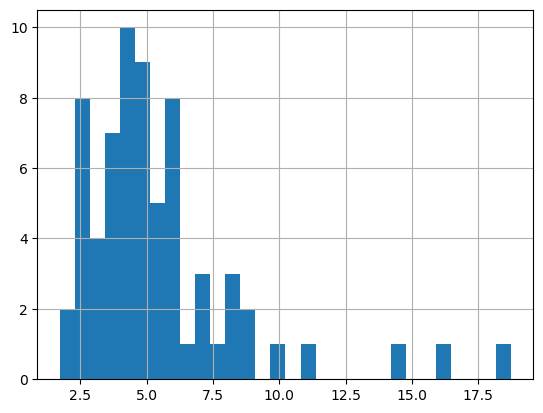

In [248]:
perc_examples_2.hist(bins=30)
plt.savefig('distribution_afetr_partial_hist_filtering_samples_Lisbon.png')

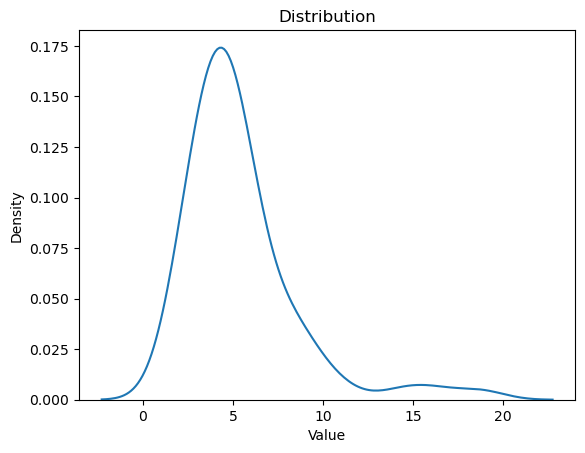

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(perc_examples_2)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.savefig('distribution_afetr_partial_filtering_samples_Lisbon.png')
plt.show()

In [250]:
list_prot_nan_2 = final_matrix.isna().sum().tolist()

In [251]:
perc_prot_2 = []
n_patients_2 = final_matrix.shape[0]
for i in list_prot_nan_2:
    res = (i/n_patients_2)*100
    perc_prot_2.append(res)

In [252]:
n_patients_2

68

In [253]:
perc_prot_2 = pd.Series(perc_prot_2)
perc_prot_2.describe()

count    347.000000
mean       5.390744
std       14.059054
min        0.000000
25%        0.000000
50%        0.000000
75%        2.941176
max       95.588235
dtype: float64

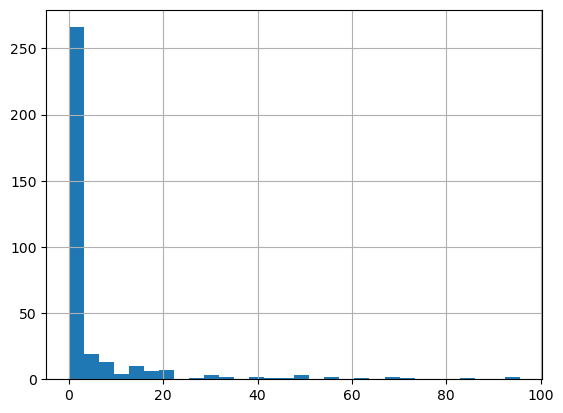

In [254]:
perc_prot_2.describe()
perc_prot_2.hist(bins=30)
plt.savefig('distribution_after_partial_filtering_hist_prot_Lisbon.png')

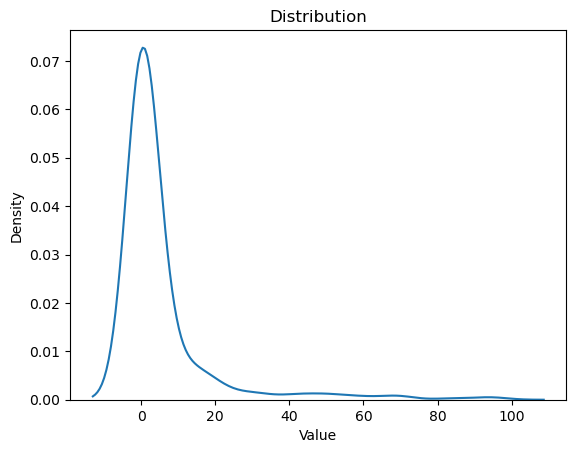

In [255]:
sns.kdeplot(perc_prot_2)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.savefig('distribution_after_partial_filtering_prot_Lisbon.png')
plt.show()

Data Filtering Based on Missing Value Thresholds

To ensure the statistical power of the analysis, a filtering step was implemented based on the percentage of missing values (NaN). Features (proteins) and observations (patients) that exceeded a predefined threshold of missingness were excluded. This process refines the dataset, retaining only the most robust and informative variables for downstream statistical testing.

In [256]:
perc_examples_2.sort_values(ascending=False).head(10)

3     18.731988
66    16.138329
48    14.409222
65    10.951009
31     9.798271
24     8.933718
64     8.933718
4      8.357349
13     8.357349
51     8.357349
dtype: float64

In [257]:
missing_per_sample = final_matrix.isna().mean(axis=1)
df_rem_pat = final_matrix.loc[missing_per_sample <= 0.10]

In [258]:
df_rem_pat

Protein.Group,A0A075B6I0,A0A0A0MS15,A0A0B4J1V0,A0A0B4J1V2,A0A0C4DH33,A0A0C4DH38,A0A0J9YX35,A6NGN9,A6NLU5,O00391,...,Q9ULB1,Q9UM22,Q9UMF0,Q9Y240,Q9Y2T3,Q9Y4C0,Q9Y5I4,Q9Y646,Q9Y6N7,Q9Y6R7
LIS090,54.8819,257.510,106.4990,59.7512,NaN,236.317,234.945,11.16520,22.2950,132.195,...,366.987,47.7775,32.5922,22.0513,57.7225,422.239,32.7511,86.1335,27.3094,870.229
LIS098,38.1270,339.818,155.1560,49.4040,177.0680,318.837,302.799,NaN,17.3181,107.058,...,294.140,53.7307,18.8195,24.6963,49.4257,435.692,23.5371,117.5790,27.2690,327.335
LIS017,53.9379,104.719,237.5140,12.8067,NaN,139.261,147.126,8.09593,NaN,111.723,...,300.873,32.8714,20.1088,46.4279,45.4786,369.049,17.2836,162.3600,25.8156,228.482
LIS026,43.3653,389.579,380.0220,80.7770,36.8618,435.268,379.957,9.24815,17.4523,150.609,...,257.991,40.0086,NaN,31.6040,62.0256,335.704,18.3222,104.1290,19.7520,460.015
LIS009,71.7777,414.481,88.8682,84.2767,21.8891,425.101,415.313,NaN,33.3922,162.382,...,234.069,43.7746,NaN,31.9584,42.5196,352.267,30.7619,84.5561,24.7463,828.819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS096,100.5910,492.736,NaN,95.0737,18.6527,429.906,298.828,NaN,18.1948,119.413,...,386.984,43.5144,22.7111,24.3609,83.2912,457.092,17.7864,86.4976,24.7507,726.382
LIS097,49.8716,383.087,NaN,107.7390,12.5278,218.211,297.109,NaN,47.3642,142.013,...,367.480,23.3986,30.9541,24.0509,56.0863,443.280,15.9279,117.2460,21.9684,747.037
LIS102,47.9074,383.533,178.1600,49.7495,14.5472,177.674,254.490,NaN,49.1510,141.446,...,498.490,53.6547,27.8752,28.6467,85.9522,551.343,23.1060,103.7710,28.2173,758.356
LIS103,127.1660,363.147,283.6140,175.4780,26.4981,688.416,537.698,5.79813,24.4566,107.267,...,257.970,NaN,17.3574,23.2611,42.6857,302.717,13.9528,80.2208,23.0786,1125.830


In [259]:
perc_prot_2.sort_values(ascending=False)

335    95.588235
65     92.647059
42     83.823529
73     70.588235
143    69.117647
         ...    
129     0.000000
128     0.000000
127     0.000000
126     0.000000
346     0.000000
Length: 347, dtype: float64

In [260]:
count = 0

for i in perc_prot_2.tolist():
    if i == 0:
        count += 1
print(count)

226


In [261]:
df_clean_Nan = df_rem_pat.dropna(axis=1)

In [262]:
df_clean_Nan

Protein.Group,A0A0A0MS15,A0A0C4DH38,O00391,O00462,O00533,O14498,O14594,O14773,O15031,O15394,...,Q9UBP4,Q9UBX1,Q9UBX5,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y240,Q9Y4C0,Q9Y646,Q9Y6R7
LIS090,257.510,236.317,132.195,29.3920,725.391,112.1150,76.8773,104.4190,53.9893,406.244,...,4050.33,177.834,204.201,78.1599,94.9574,366.987,22.0513,422.239,86.1335,870.229
LIS098,339.818,318.837,107.058,38.0315,593.904,97.5117,50.2521,113.9820,73.2653,301.265,...,3125.65,152.211,219.854,72.8937,76.0250,294.140,24.6963,435.692,117.5790,327.335
LIS017,104.719,139.261,111.723,38.8967,625.250,112.7310,93.3398,126.1180,69.2886,343.986,...,3268.02,199.536,287.378,62.6349,96.9738,300.873,46.4279,369.049,162.3600,228.482
LIS026,389.579,435.268,150.609,31.3645,585.965,89.8327,65.5730,111.7700,44.3342,393.803,...,3028.24,173.605,282.750,128.1580,80.0471,257.991,31.6040,335.704,104.1290,460.015
LIS009,414.481,425.101,162.382,27.1541,666.602,120.5120,69.3553,101.2390,50.7078,360.188,...,3036.01,168.839,195.598,144.9920,97.2441,234.069,31.9584,352.267,84.5561,828.819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS096,492.736,429.906,119.413,38.9747,587.127,84.2547,141.2820,95.8070,59.2189,325.720,...,2636.01,106.448,224.896,59.1876,127.0380,386.984,24.3609,457.092,86.4976,726.382
LIS097,383.087,218.211,142.013,23.7018,540.711,153.3680,110.5990,62.5076,53.7906,252.568,...,2602.63,171.315,257.396,77.2557,84.9797,367.480,24.0509,443.280,117.2460,747.037
LIS102,383.533,177.674,141.446,27.1632,837.668,141.2360,156.0800,95.4981,63.6703,394.627,...,2532.82,137.854,251.883,65.1544,67.5648,498.490,28.6467,551.343,103.7710,758.356
LIS103,363.147,688.416,107.267,24.0963,372.151,159.6460,49.1715,69.3911,55.1556,257.433,...,1782.24,147.799,210.313,65.4459,45.1448,257.970,23.2611,302.717,80.2208,1125.830


In [263]:
df_clean_Nan.isnull().sum().sum()

0

In [264]:
#list_protein_original_matrix = df['Protein.Group'].tolist()

In [265]:
#list_protein_modified_matrix = df_clean_Nan.columns.tolist()

In [266]:
'''
final_list = []
for i in list_protein_modified_matrix:
    for j in list_protein_original_matrix:
        if i == j :
            final_list.append(i)
print(len(final_list))
'''

'\nfinal_list = []\nfor i in list_protein_modified_matrix:\n    for j in list_protein_original_matrix:\n        if i == j :\n            final_list.append(i)\nprint(len(final_list))\n'

In [267]:
#prot_final_list = list(set(list_protein_original_matrix).intersection(set(list_protein_modified_matrix)))

In [268]:
#len(prot_final_list)

In [269]:
#final_matrix = df_clean_Nan[prot_final_list]

In [270]:
#final_matrix

In [271]:
#(final_matrix == 0).sum().sum()

LOG2 TRANFORMATION

Data Transformation and Post-Normalization AssessmentProtein intensities were $\log_2$-transformed to stabilize variance and reduce the skewness of the data distribution. Following the transformation, we re-evaluated the dataset using boxplots and correlation heatmaps. This step ensures that the transformation successfully homogenized the signal across samples and prepared the data for robust statistical comparisons.

In [272]:
data_log2 = np.log2(df_clean_Nan)

In [273]:
data_log2

Protein.Group,A0A0A0MS15,A0A0C4DH38,O00391,O00462,O00533,O14498,O14594,O14773,O15031,O15394,...,Q9UBP4,Q9UBX1,Q9UBX5,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y240,Q9Y4C0,Q9Y646,Q9Y6R7
LIS090,8.008485,7.884580,7.046524,4.877352,9.502615,6.808836,6.264486,6.706240,5.754602,8.666203,...,11.983824,7.474387,7.673846,6.288357,6.569209,8.519585,4.462792,8.721916,6.428503,9.765251
LIS098,8.408618,8.316675,6.742249,5.249123,9.214086,6.607503,5.651112,6.832662,6.195058,8.234889,...,11.609941,7.249929,7.780402,6.187722,6.248402,8.200359,4.626223,8.767165,6.877487,8.354624
LIS017,6.710379,7.121647,6.803782,5.281576,9.288289,6.816740,6.544420,6.978630,6.114546,8.426206,...,11.674201,7.640505,8.166806,5.968895,6.599523,8.233011,5.536920,8.527669,7.343052,7.835937
LIS026,8.605772,8.765760,7.234664,4.971061,9.194671,6.489169,6.035030,6.804389,5.470348,8.621330,...,11.564264,7.439665,8.143383,7.001780,6.322777,8.011177,4.982035,8.391046,6.702228,8.845537
LIS009,8.695162,8.731662,7.343248,4.763098,9.380682,6.913033,6.115934,6.661621,5.664136,8.492606,...,11.567961,7.399504,7.611748,7.179829,6.603539,7.870790,4.998123,8.460526,6.401837,9.694913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS096,8.944671,8.747877,6.899816,5.284466,9.197529,6.396685,7.142434,6.582059,5.887986,8.347488,...,11.364140,6.734005,7.813114,5.887223,6.989116,8.596130,4.606496,8.836341,6.434588,9.504585
LIS097,8.581528,7.769580,7.149879,4.566925,9.078714,7.260854,6.789195,5.965960,5.749282,7.980528,...,11.345755,7.420508,8.007846,6.271569,6.409046,8.521522,4.588019,8.792074,6.873395,9.545036
LIS102,8.583207,7.473089,7.144108,4.763582,9.710235,7.141964,7.286142,6.577400,5.992549,8.624346,...,11.306529,7.106997,7.976610,6.025791,6.078200,8.961421,4.840297,9.106806,6.697260,9.566731
LIS103,8.504410,9.427137,6.745062,4.590740,8.539744,7.318733,5.619750,6.116679,5.785435,8.008053,...,10.799476,7.207493,7.716394,6.032231,5.496488,8.011059,4.539847,8.241826,6.325904,10.136773


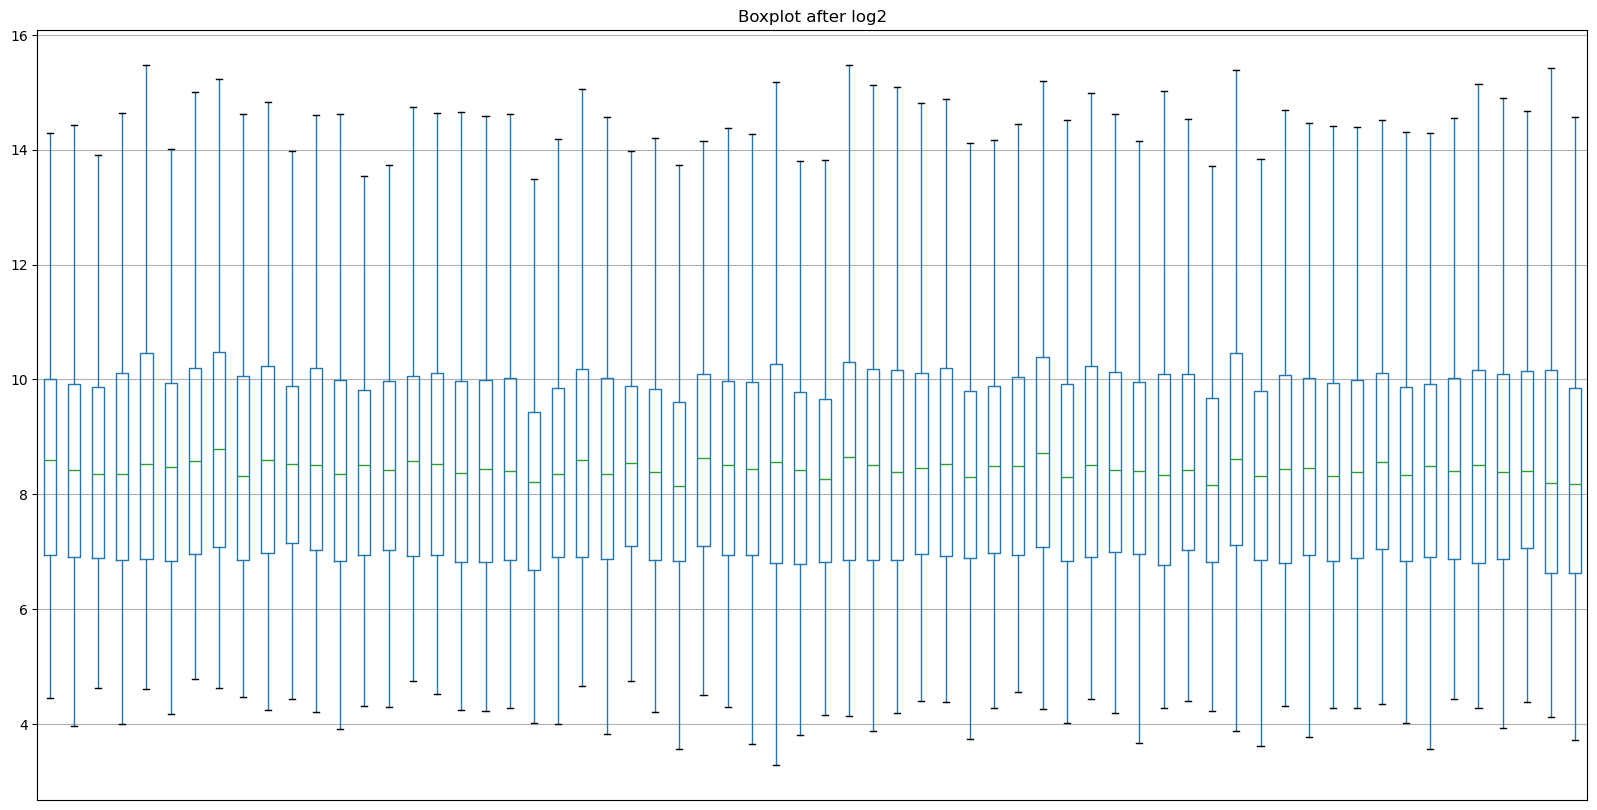

In [274]:
plt.figure(figsize=(20,10))
data_log2.T.boxplot(showfliers=False)
plt.xticks([])
plt.title("Boxplot after log2")
plt.savefig('Boxplot_dopo_log2_Lisbon.png')
plt.show()

In [ ]:
corr_matrix = data_log2.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="viridis")
plt.title("Correlation heatmap - log2")
plt.savefig('Correlation heatmap - log2')
plt.show()

In [ ]:
data_log2

In [ ]:
normalized_datalog2 = (data_log2 - data_log2.min())/(data_log2.max()-data_log2.min())

In [ ]:
normalized_datalog2

In [ ]:
z_score_df = (data_log2-data_log2.mean())/data_log2.std()

In [ ]:
z_score_df

In [ ]:
plt.figure(figsize=(25,10))
z_score_df.boxplot(showfliers=False, showmeans=True, meanline=True,meanprops={
        'color': 'red',         
        'linewidth': 1,         
        'linestyle': '--'      
    },)
plt.xticks([])   
plt.title("protein boxplot after z-score")
plt.savefig('protein_boxplot_after_z-score_Lisbon')
plt.show()

In [ ]:
data_log2

In [ ]:
df_MCI = pd.read_excel('sample_information.xlsx', header=1, usecols="C:F")

In [ ]:
df_MCI

In [ ]:
df_all_data = data_log2.merge(df_MCI, left_index=True, right_on='Sample code', how='left')

In [ ]:
df_all_data

In [ ]:
list_groups = df_all_data['Groups'].tolist()

In [ ]:
df_all_data['Gender'].unique()

In [ ]:
df_ad_ct = df_all_data[(df_all_data['Groups']=='MCI-AD') | (df_all_data['Groups']=='MCI-CT')]

In [ ]:
df_ad_ct

In [ ]:
df_ad_ct['Groups'].unique()

In [ ]:
ad = df_ad_ct[df_ad_ct['Groups']=='MCI-AD']
ad_prot = ad.drop(columns=['Groups'])
ad_prot = ad_prot.drop(columns=['Gender'])
ad_prot = ad_prot.drop(columns=['Age'])
ad_prot = ad_prot.drop(columns=['Sample code'])

In [ ]:
ct = df_ad_ct[df_ad_ct['Groups']=='MCI-CT']
ct_prot = ct.drop(columns=['Groups'])
ct_prot = ct_prot.drop(columns=['Gender'])
ct_prot = ct_prot.drop(columns=['Age'])
ct_prot = ct_prot.drop(columns=['Sample code'])

In [ ]:
log2fc = ad_prot.mean() - ct_prot.mean()

In [ ]:
from scipy.stats import ttest_ind
p_values = []

for protein in ad_prot.columns:
    stat, p = ttest_ind(ad_prot[protein], ct_prot[protein], nan_policy="omit")
    p_values.append(p)

p_values = pd.Series(p_values, index=ad_prot.columns)

In [ ]:
results = pd.DataFrame({
    "log2FC": log2fc,
    "pvalue": p_values
})

results["neg_log10_p"] = -np.log10(results["pvalue"])
import numpy as np

results["color"] = "grey"

results.loc[(results["pvalue"] < 0.05) & (results["log2FC"] > 0), "color"] = "red"
results.loc[(results["pvalue"] < 0.05) & (results["log2FC"] < 0), "color"] = "blue"

In [ ]:
results

In [ ]:
plt.figure(figsize=(10,8))
proteins_to_label = [
    "P02763","Q14118","Q13449","P54289","P40925",
    "Q16270","P25311","P14618","O94769","P07333"
]
# non significative
plt.scatter(
    results.loc[results["color"] == "grey", "log2FC"],
    results.loc[results["color"] == "grey", "neg_log10_p"],
    color="grey",
    alpha=0.5,
    label="Not significant"
)

# up in AD
plt.scatter(
    results.loc[results["color"] == "red", "log2FC"],
    results.loc[results["color"] == "red", "neg_log10_p"],
    color="red",
    alpha=0.8,
    label="Up in AD"
)

# up in CT
plt.scatter(
    results.loc[results["color"] == "blue", "log2FC"],
    results.loc[results["color"] == "blue", "neg_log10_p"],
    color="blue",
    alpha=0.8,
    label="Up in CT"
)

plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("log2 Fold Change (AD vs CT)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot MCI-AD vs MCI-CT PLSDA Lisbon")

plt.legend()

for protein in proteins_to_label:
    if protein in results.index:
        x = results.loc[protein, "log2FC"]
        y = results.loc[protein, "neg_log10_p"]

        plt.text(
            x, y,
            protein,
            fontsize=9,
            ha='right',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )
plt.savefig('Volcano_Plot_plsda_Lisbon')
plt.show()

In [ ]:
from statsmodels.stats.multitest import multipletests

results["FDR"] = multipletests(results["pvalue"], method="fdr_bh")[1]

In [ ]:
significant = results[(results["FDR"] < 0.05)]
print(len(significant))

In [ ]:
import matplotlib.pyplot as plt

proteins = df_all_data.iloc[:, :-4]  # colonne proteine
age = df_all_data["Age"]

correlations = proteins.apply(lambda x: x.corr(df_all_data["Age"]))
corr_sorted = correlations.sort_values()

top_neg = corr_sorted.head(10)
top_pos = corr_sorted.tail(10)

top = pd.concat([top_neg, top_pos])

top.plot(kind="bar", figsize=(12,6))
plt.title("Correlation_age_protein_Lisbon")
plt.savefig('Correlation_age_protein_Lisbon')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

proteins = df_all_data.iloc[:, :-4]

df_long = proteins.copy()
df_long["Gender"] = df_all_data["Gender"]

df_long = df_long.melt(id_vars="Gender",
                       var_name="Protein",
                       value_name="Intensity")

plt.figure(figsize=(8,6))

df_long.boxplot(column="Intensity", by="Gender", showfliers=False)

plt.title("Protein intensity distribution by sex Lisbon")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Protein intensity")
plt.savefig('Protein_intensity_distribution_by_sex_Lisbon.png')
plt.show()

In [ ]:
z_score_df.to_pickle('matrix_Lisbon_threshold.pkl')

In [ ]:
import pickle
with open('list_groups.pkl', 'wb') as f:
    pickle.dump(list_groups, f)

In [ ]:
data_log2.to_pickle('data_log2_Lisbon_threshold.pkl')

In [ ]:
ax = sns.countplot(
    data=df_all_data,
    x='Groups',
    palette={'MCI-AD': 'green', 'MCI-CT': 'orange'}
)

# aggiungi numeri
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title('Number of patients per group Lisbon with threshold')
plt.ylabel('Count')
plt.savefig('Number_of_patient_per_group_Lisbon_threshold')
plt.show()